# Previsão de Produção — 78 Semanas Futuras

Notebook enxuto: carrega dado → engenharia de features → **configuração de roteamento final** (resultado de toda a investigação no notebook de Experimentos) → treina cada SKU-canal no **histórico completo** (sem holdout -- isso é previsão real, não validação) → gera a previsão recursiva das 78 semanas futuras → gráficos de linha (histórico + previsão) por combinação.

> Requisitos: `pip install lightgbm pygam pandas numpy matplotlib openpyxl`


## 0. Libraries e Load Data

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l, f

warnings.filterwarnings("ignore")

DATA_PATH = "Business_Case_Data_Set.xlsx"
OUTDIR = Path("output")
OUTDIR.mkdir(exist_ok=True, parents=True)

xl = pd.ExcelFile(DATA_PATH)
ext = xl.parse("Table 1 - External Variables")   # cobre as 234 semanas (156 historicas + 78 futuras)
actual = xl.parse("Table 2 - Sell In")            # so cobre as 156 semanas historicas

raw = ext.merge(actual, on=["Week", "Product", "Channel"], how="left")  # LEFT: mantem as 78 futuras, Sell_In_Tons = NaN
raw["Week"] = pd.to_datetime(raw["Week"])
raw = raw.sort_values(["Product", "Channel", "Week"]).reset_index(drop=True)
raw["Week_Index"] = raw.groupby(["Product", "Channel"]).cumcount()

n_hist = raw["Sell_In_Tons"].notna().sum()
n_future = raw["Sell_In_Tons"].isna().sum()
print(f"{len(raw)} linhas totais | {n_hist} historicas (com Sell-In real) | {n_future} futuras (a prever)")
print(f"Ultima semana historica: {raw[raw['Sell_In_Tons'].notna()]['Week'].max().date()}")
print(f"Ultima semana futura:    {raw['Week'].max().date()}")


3510 linhas totais | 2340 historicas (com Sell-In real) | 1170 futuras (a prever)
Ultima semana historica: 2026-06-22
Ultima semana futura:    2027-12-20


### Feature engineering (só no histórico -- o futuro é construído recursivamente, célula abaixo)

In [2]:
TARGET_COL = "Sell_In_Tons"

FEATURE_COLS = [
    "Price_per_kg_USD", "Numeric_Distribution", "Weighted_Distribution",
    "Advertising_Investment_USD", "Promotion_Investment_USD", "Promo_Flag",
    "Lag_1w", "Lag_4w", "Rolling_Mean_4w", "Rolling_Std_4w",
    "Price_Change_Pct", "Month_Sin", "Month_Cos", "Holiday_Flag",
    "Interaction_Price_Promo",
]
FEATURE_COLS_GAM = [
    "Week_Index", "Month_Sin", "Month_Cos", "Price_per_kg_USD",
    "Numeric_Distribution", "Weighted_Distribution", "Advertising_Investment_USD",
    "Promotion_Investment_USD", "Promo_Flag", "Lag_1w", "Price_Change_Pct",
    "Interaction_Price_Promo",
]

SKU_LEVEL_PARAMS = dict(
    n_estimators=500, learning_rate=0.1, max_depth=4, num_leaves=15,
    min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0, min_split_gain=0.0,
    boosting_type="gbdt", objective="regression", metric="mape",
    random_state=42, n_jobs=-1, verbose=-1,
)


def add_price_monotone_constraint(params, feature_cols, price_col="Price_per_kg_USD"):
    constrained = dict(params)
    constrained["monotone_constraints"] = tuple(-1 if c == price_col else 0 for c in feature_cols)
    return constrained


def engineer_features(df):
    """So deve ser aplicado ao HISTORICO (Sell_In_Tons conhecido) -- usa shift/rolling
    que dependem do target real, entao nao faz sentido para as semanas futuras."""
    df = df.copy()
    df["Promo_Flag"] = df["Promotion_Type"].notna().astype(int)
    g_target = df.groupby(["Product", "Channel"])[TARGET_COL]
    df["Lag_1w"] = g_target.shift(1)
    df["Lag_4w"] = g_target.shift(4)
    shifted = g_target.shift(1)
    grouped_shifted = shifted.groupby([df["Product"], df["Channel"]])
    df["Rolling_Mean_4w"] = grouped_shifted.rolling(4).mean().reset_index(level=[0, 1], drop=True)
    df["Rolling_Std_4w"] = grouped_shifted.rolling(4).std().reset_index(level=[0, 1], drop=True)
    df["Price_Change_Pct"] = df.groupby(["Product", "Channel"])["Price_per_kg_USD"].pct_change()
    month = df["Week"].dt.month
    df["Month_Sin"] = np.sin(2 * np.pi * month / 12)
    df["Month_Cos"] = np.cos(2 * np.pi * month / 12)
    df["Holiday_Flag"] = 0  # sem calendario de feriados disponivel no dataset (ver notebook de Experimentos)
    df["Interaction_Price_Promo"] = df["Price_per_kg_USD"] * df["Promo_Flag"]
    return df.dropna(subset=FEATURE_COLS + [TARGET_COL]).reset_index(drop=True)


raw_hist = raw[raw[TARGET_COL].notna()].copy()
train_full = engineer_features(raw_hist)   # TODO o historico -- sem holdout, e producao real
print(f"Treino final (historico completo, sem holdout): {len(train_full)} linhas")


Treino final (historico completo, sem holdout): 2280 linhas


## 1. Configuração de roteamento final

Resultado consolidado de toda a investigação no notebook de Experimentos: bake-off recursivo (Seção 6), override manual pra Whole Grain Crackers/Supermercados (Seção 7/13, GAM em vez de Stacked -- restrição não sustentável no Stacked), os dois SKU-canal de E-commerce roteados normalmente (não mais "NONE stable", já que provamos que WAPE é a métrica certa pra eles), e **reavaliado via WAPE em vez de MAPE** (Seção 17) -- 1 de 15 combinações mudou (Flavored Water/Supermercados: `Pooled_LightGBM` → `LightGBM`).

**Simplificação deliberada**: usamos só as 3 famílias mais robustas (LightGBM SKU-level, GAM SKU-level, LightGBM Pooled) -- as variantes exploratórias (Tuned, MapeObj, Lag52, L2Weighted) tiveram ganho inconsistente e adicionam fragilidade (várias esbarraram em incompatibilidades reais da lib, ver Seções 11/15/16 do notebook de Experimentos). Se alguma delas vencer de forma consistente e validada no seu ambiente, é só adicionar aqui.

In [3]:
FINAL_ROUTING = {
    ("Energy Drink 350ml", "Traditional"): "GAM",
    ("Cereal Bar 50g", "E-commerce"): "LightGBM",
    ("Energy Drink 350ml", "Supermarkets"): "GAM",
    ("Natural Juice 1L", "Traditional"): "GAM",
    ("Whole Grain Crackers 200g", "E-commerce"): "LightGBM",
    ("Cereal Bar 50g", "Supermarkets"): "LightGBM",
    ("Whole Grain Crackers 200g", "Supermarkets"): "GAM",  # override manual -- ver Secao 7/13
    ("Natural Juice 1L", "Supermarkets"): "LightGBM",
    ("Flavored Water 500ml", "Supermarkets"): "LightGBM",  # atualizado: avaliado via WAPE (Secao 17 do Experimentos), era Pooled_LightGBM sob MAPE
    ("Natural Juice 1L", "E-commerce"): "LightGBM",
    ("Flavored Water 500ml", "Traditional"): "GAM",
    ("Whole Grain Crackers 200g", "Traditional"): "LightGBM",
    ("Cereal Bar 50g", "Traditional"): "LightGBM",
    ("Energy Drink 350ml", "E-commerce"): "LightGBM",       # avaliar via WAPE, nao MAPE
    ("Flavored Water 500ml", "E-commerce"): "Pooled_LightGBM",  # avaliar via WAPE, nao MAPE
}

routing_df = pd.DataFrame(
    [{"Product": p, "Channel": c, "Model_Family": m} for (p, c), m in FINAL_ROUTING.items()]
)
print(routing_df.to_string(index=False))
print()
print(routing_df["Model_Family"].value_counts().to_string())


                  Product      Channel    Model_Family
       Energy Drink 350ml  Traditional             GAM
           Cereal Bar 50g   E-commerce        LightGBM
       Energy Drink 350ml Supermarkets             GAM
         Natural Juice 1L  Traditional             GAM
Whole Grain Crackers 200g   E-commerce        LightGBM
           Cereal Bar 50g Supermarkets        LightGBM
Whole Grain Crackers 200g Supermarkets             GAM
         Natural Juice 1L Supermarkets        LightGBM
     Flavored Water 500ml Supermarkets        LightGBM
         Natural Juice 1L   E-commerce        LightGBM
     Flavored Water 500ml  Traditional             GAM
Whole Grain Crackers 200g  Traditional        LightGBM
           Cereal Bar 50g  Traditional        LightGBM
       Energy Drink 350ml   E-commerce        LightGBM
     Flavored Water 500ml   E-commerce Pooled_LightGBM

Model_Family
LightGBM           9
GAM                5
Pooled_LightGBM    1


## 2. Treinar cada SKU-canal com o modelo escolhido (histórico completo, sem holdout)

In [4]:
class GAMModelWrapper:
    def __init__(self, feature_cols, n_splines=8, lam=0.6):
        self.feature_cols = feature_cols
        self.n_splines = n_splines
        self.lam = lam
        self.model = None

    def _build_terms(self):
        terms = None
        for i, col in enumerate(self.feature_cols):
            if col == "Week_Index":
                term = s(i, n_splines=self.n_splines, lam=self.lam)
            elif col == "Price_per_kg_USD":
                term = s(i, n_splines=self.n_splines, lam=self.lam, constraints="monotonic_dec")
            elif col in ("Month_Sin", "Month_Cos"):
                term = s(i, n_splines=self.n_splines, lam=self.lam)
            elif col == "Promo_Flag":
                term = f(i)
            else:
                term = l(i)
            terms = term if terms is None else terms + term
        return terms

    def fit(self, X, y):
        self.model = LinearGAM(self._build_terms()).fit(X[self.feature_cols].values, y.values)
        return self

    def predict(self, X):
        return self.model.predict(X[self.feature_cols].values)


final_models = {}       # (product, channel) -> modelo treinado
final_feature_cols = {}  # (product, channel) -> lista de features que esse modelo usa

# --- LightGBM SKU-level (com restricao) ---
for (product, channel), family in FINAL_ROUTING.items():
    if family != "LightGBM":
        continue
    sub = train_full[(train_full.Product == product) & (train_full.Channel == channel)]
    params = add_price_monotone_constraint(SKU_LEVEL_PARAMS, FEATURE_COLS)
    model = lgb.LGBMRegressor(**params)
    model.fit(sub[FEATURE_COLS], sub[TARGET_COL])
    final_models[(product, channel)] = model
    final_feature_cols[(product, channel)] = FEATURE_COLS

# --- GAM SKU-level (restricao nativa) ---
for (product, channel), family in FINAL_ROUTING.items():
    if family != "GAM":
        continue
    sub = train_full[(train_full.Product == product) & (train_full.Channel == channel)]
    model = GAMModelWrapper(FEATURE_COLS_GAM)
    model.fit(sub[FEATURE_COLS_GAM], sub[TARGET_COL])
    final_models[(product, channel)] = model
    final_feature_cols[(product, channel)] = FEATURE_COLS_GAM

# --- LightGBM Pooled (com restricao) -- um modelo por canal, reaproveitado pelos produtos roteados a ele ---
pooled_channels_needed = {c for (p, c), fam in FINAL_ROUTING.items() if fam == "Pooled_LightGBM"}
pooled_models = {}
for channel in pooled_channels_needed:
    sub = train_full[train_full.Channel == channel]
    params = add_price_monotone_constraint(SKU_LEVEL_PARAMS, FEATURE_COLS)
    model = lgb.LGBMRegressor(**params)
    model.fit(sub[FEATURE_COLS], sub[TARGET_COL])
    pooled_models[channel] = model

for (product, channel), family in FINAL_ROUTING.items():
    if family != "Pooled_LightGBM":
        continue
    final_models[(product, channel)] = pooled_models[channel]
    final_feature_cols[(product, channel)] = FEATURE_COLS

print(f"{len(final_models)} modelos finais treinados (histórico completo, sem holdout).")


15 modelos finais treinados (histórico completo, sem holdout).


## 3. Previsão recursiva das 78 semanas futuras

Mesma lógica do backtest recursivo do notebook de Experimentos, mas agora genuinamente prevendo o futuro (sem Sell-In real disponível) -- cada previsão vira o "Lag_1w" da semana seguinte, e assim por diante.

In [5]:
def forecast_future_sku(model, feature_cols, raw_df, product, channel):
    sub = raw_df[(raw_df["Product"] == product) & (raw_df["Channel"] == channel)].sort_values("Week").reset_index(drop=True)
    hist_idx = sub.index[sub[TARGET_COL].notna()].tolist()
    future_idx = sub.index[sub[TARGET_COL].isna()].tolist()
    if not future_idx:
        return pd.DataFrame()

    history = sub.loc[hist_idx, TARGET_COL].tolist()  # burn-in: Sell-In real, ate a ultima semana historica
    week_index_counter = len(hist_idx)  # continua a contagem do Week_Index de onde o historico parou

    rows = []
    for horizon, idx in enumerate(future_idx, start=1):
        row = sub.loc[idx]
        promo_flag = int(pd.notna(row["Promotion_Type"]))
        prev_price = sub.loc[idx - 1, "Price_per_kg_USD"] if (idx - 1) in sub.index else np.nan
        price_change_pct = ((row["Price_per_kg_USD"] - prev_price) / prev_price
                             if pd.notna(prev_price) and prev_price != 0 else np.nan)
        month = row["Week"].month

        feat = {
            "Week_Index": week_index_counter,
            "Price_per_kg_USD": row["Price_per_kg_USD"],
            "Numeric_Distribution": row["Numeric_Distribution"],
            "Weighted_Distribution": row["Weighted_Distribution"],
            "Advertising_Investment_USD": row["Advertising_Investment_USD"],
            "Promotion_Investment_USD": row["Promotion_Investment_USD"],
            "Promo_Flag": promo_flag,
            "Lag_1w": history[-1],
            "Lag_4w": history[-4] if len(history) >= 4 else history[0],
            "Rolling_Mean_4w": float(np.mean(history[-4:])),
            "Rolling_Std_4w": float(np.std(history[-4:], ddof=1)) if len(history[-4:]) > 1 else 0.0,
            "Price_Change_Pct": price_change_pct,
            "Month_Sin": np.sin(2 * np.pi * month / 12),
            "Month_Cos": np.cos(2 * np.pi * month / 12),
            "Holiday_Flag": 0,
            "Interaction_Price_Promo": row["Price_per_kg_USD"] * promo_flag,
        }
        X_row = pd.DataFrame([feat])[feature_cols]
        pred = float(model.predict(X_row)[0])
        pred = max(pred, 0.0)  # Sell-In nao pode ser negativo

        rows.append({"Product": product, "Channel": channel, "Week": row["Week"],
                      "Horizon": horizon, "Predicted": pred})
        history.append(pred)
        week_index_counter += 1

    return pd.DataFrame(rows)


all_forecasts = []
for (product, channel), model in final_models.items():
    fc = forecast_future_sku(model, final_feature_cols[(product, channel)], raw, product, channel)
    all_forecasts.append(fc)

forecast_78w = pd.concat(all_forecasts, ignore_index=True)
print(f"Previsao gerada: {len(forecast_78w)} linhas ({forecast_78w['Product'].nunique()} produtos x "
      f"{forecast_78w['Channel'].nunique()} canais x {forecast_78w['Horizon'].max()} semanas).")
forecast_78w.to_csv(OUTDIR / "forecast_78_semanas.csv", index=False)
forecast_78w.head()


Previsao gerada: 1170 linhas (5 produtos x 3 canais x 78 semanas).


,Product,Channel,Week,Horizon,Predicted
0,Cereal Bar 50g,E-commerce,2026-06-29,1,0.996022
1,Cereal Bar 50g,E-commerce,2026-07-06,2,1.046139
2,Cereal Bar 50g,E-commerce,2026-07-13,3,0.946753
3,Cereal Bar 50g,E-commerce,2026-07-20,4,1.001454
4,Cereal Bar 50g,E-commerce,2026-07-27,5,1.006911


## 4. Gráficos: histórico + previsão, por combinação

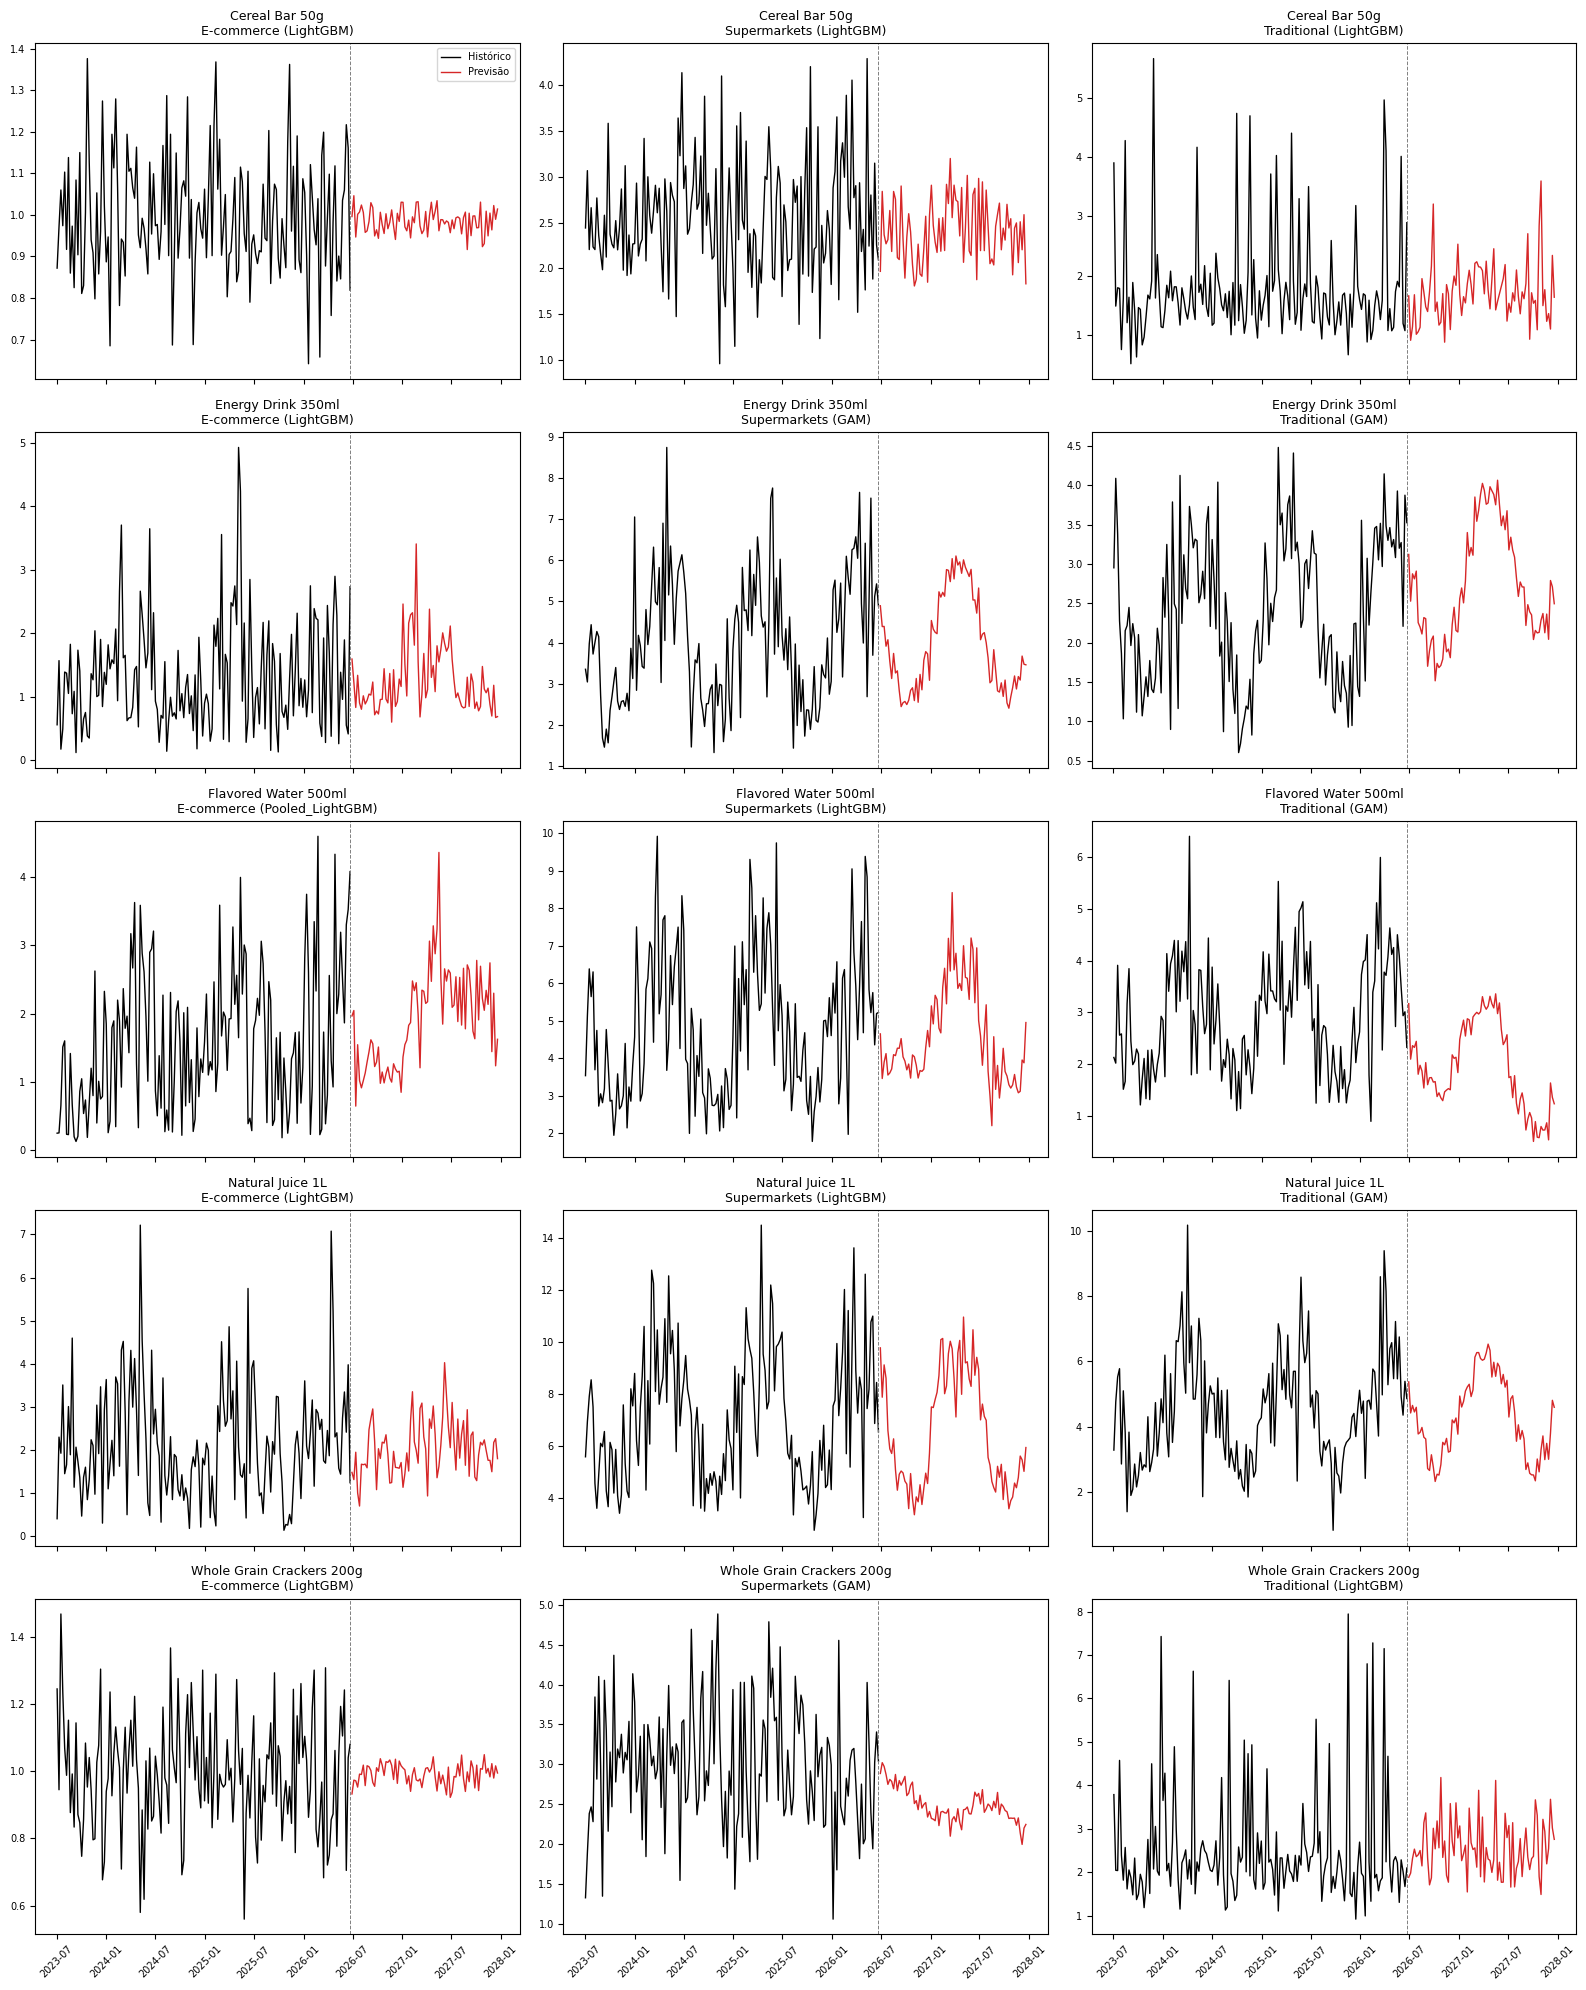

In [6]:
products = sorted(raw["Product"].unique())
channels = sorted(raw["Channel"].unique())

fig, axes = plt.subplots(len(products), len(channels), figsize=(16, 20), sharex=True)

for i, product in enumerate(products):
    for j, channel in enumerate(channels):
        ax = axes[i, j]
        hist = raw[(raw.Product == product) & (raw.Channel == channel) & (raw[TARGET_COL].notna())]
        fc = forecast_78w[(forecast_78w.Product == product) & (forecast_78w.Channel == channel)]

        ax.plot(hist["Week"], hist[TARGET_COL], color="black", linewidth=1, label="Histórico")
        ax.plot(fc["Week"], fc["Predicted"], color="#d62728", linewidth=1, label="Previsão")
        ax.axvline(hist["Week"].max(), color="gray", linestyle="--", linewidth=0.7)

        family = FINAL_ROUTING.get((product, channel), "?")
        ax.set_title(f"{product}\n{channel} ({family})", fontsize=9)
        ax.tick_params(axis="x", labelsize=7, rotation=45)
        ax.tick_params(axis="y", labelsize=7)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

fig.tight_layout()
plt.show()
